# Feature exploration and selection — new data (no PM2.5 anchor)

**Team overfitters.** This notebook is the running log of *what was tested, what worked, and
why* for the new training data. It reads the measured results in `artifacts/v3/results/`
(produced by `scripts/v3/run_experiment.py`) rather than retraining, so every number here is
the same number in `Findings/v3/`.

Companion documents: [`new data/migration.md`](../../new%20data/migration.md) (what changed),
[`notebooks/eda_v2/`](../eda_v2/01_eda_new_data.ipynb) (what signal is left),
[`plan v3 changed/`](../../plan%20v3%20changed/) (the plans), [`Findings/v3/`](../../Findings/v3/).

## The setup, in one paragraph

Predict `PM2_5_next_hour` from PM10, SO2, NO2, CO, O3, weather, station and time — with the
old anchor `current_PM2_5` deleted from both train and test. Every feature is built on a
complete hourly grid per station and looks strictly backward (verified by rebuilding the panel
on truncated data and checking nothing changes). Scoring is RMSE on four time-ordered folds;
the **headline is the mean over the two heating-season folds** (Sep–Feb, the test period's
season). The yardstick is LightGBM on the raw columns: **30.80**. The goal is **17.0**.

## Method in one line

Build feature groups cumulatively, one group per run, keep what moves the headline by more
than noise on both heating folds; then change what the model *predicts*; then prune.

## 1. Setup

In [1]:
import json, sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")


def find_root(p: Path) -> Path:
    for cand in [p, *p.parents]:
        if (cand / "PROJECT.md").exists():
            return cand
    return p


ROOT = find_root(Path.cwd())
RES = ROOT / "artifacts" / "v3" / "results"
FIGS = ROOT / "reports" / "figures" / "features_new"
FIGS.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(ROOT / "scripts" / "v3"))
sys.path.insert(0, str(ROOT / "scripts" / "v2"))
sys.path.insert(0, str(ROOT / "src"))

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 140, "figure.autolayout": True,
                     "axes.edgecolor": "#9aa7b4", "grid.color": "#dfe4e9", "grid.linewidth": 0.7})
INK, MUTED, POS, NEG = "#22303f", "#9aa7b4", "#e34948", "#2a78d6"
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
DIVERGING = LinearSegmentedColormap.from_list("div", [NEG, "#f0efec", POS])


def load(name):
    p = RES / f"{name}.json"
    return json.loads(p.read_text()) if p.exists() else None


def row(name, label=None):
    r = load(name)
    if r is None:
        return None
    f = r["folds"]
    d = {"run": label or name, "cols": r["n_features"], "target": r["target"]}
    for x in f:
        d[f"fold {x['fold']}"] = round(x["rmse_all"], 2)
    d["headline"] = round(r["summary"]["headline"], 3)
    d["all-fold mean"] = round(r["summary"]["mean_all_folds"], 2)
    t0, t2 = f[0]["tails"], f[2]["tails"]
    d["falls f2"] = round(t2["fall"]["rmse"], 1)
    d["calm f2"] = round(t2["calm"]["rmse"], 1)
    d["rises f2"] = round(t2["rise"]["rmse"], 1)
    return d


def table(names):
    rows = [row(n, l) for n, l in names]
    df = pd.DataFrame([r for r in rows if r]).set_index("run")
    df["Δ vs previous"] = df["headline"].diff().round(3)
    return df


def save(fig, name):
    fig.savefig(FIGS / f"{name}.png", bbox_inches="tight")


print("root:", ROOT)

root: /Users/keithandre/Documents/GitHub/overfitters


## 2. The feature panel

`scripts/v3/features_v3.py` builds every group. The groups, and why each exists:

In [2]:
from features_v3 import load_panel, feature_sets, DIAG
panel, groups = load_panel()
sets = feature_sets(groups)

why = {
    "raw": "the ten measured columns at hour t",
    "calendar": "hour/day-of-year/day-of-week as sin/cos, heating-season flag",
    "wind": "wind direction as sin/cos and u/v vectors; wd and station as categoricals",
    "missing": "is-missing flag per column",
    "quality": "sensor floors/ceilings, flat-run counters, gap since previous row",
    "physical": "dew-point depression, combustion ratios, PM10 x humidity/wind/CO, logs",
    "lags": "each pollutant 1, 2, 3, 6, 12, 24 hours ago",
    "weather_lags": "each weather column 1, 3, 6, 24 hours ago",
    "rolling": "trailing mean/std/min/max over 3-24h for PM10, CO, NO2; position in 24h range",
    "motion1": "FIRST derivative: 1/3/6/24h change of each pollutant; weather tendencies",
    "motion2": "SECOND derivative: change of the change (acceleration) for PM10, CO, NO2",
    "network_levels": "same-hour mean/median/std/max across the other stations; deviation from them",
    "network_momentum": "how much the other stations moved in the last 1h/3h; how many are rising/falling",
    "neighbors": "each other station's PM10 level, PM10 change and CO level as its own column",
    "meteo_v2": "rain rolling sum, wind x humidity, wind x deviation-from-network",
    "deep": "fine-fraction physics: PM10 x each combustion tracer, combustion per coarse particle, city-level products",
}
pd.DataFrame({"columns": {g: len(c) for g, c in groups.items()}, "what it is": why}).loc[list(groups)]

,columns,what it is
raw,10,the ten measured columns at hour t
calendar,13,"hour/day-of-year/day-of-week as sin/cos, heati..."
wind,6,wind direction as sin/cos and u/v vectors; wd ...
missing,11,is-missing flag per column
quality,6,"sensor floors/ceilings, flat-run counters, gap..."
physical,9,"dew-point depression, combustion ratios, PM10 ..."
lags,30,"each pollutant 1, 2, 3, 6, 12, 24 hours ago"
weather_lags,20,"each weather column 1, 3, 6, 24 hours ago"
rolling,58,"trailing mean/std/min/max over 3-24h for PM10,..."
motion1,32,FIRST derivative: 1/3/6/24h change of each pol...


In [3]:
pd.Series({k: len(v) for k, v in sets.items()}, name="columns").to_frame().T

,f0_base,f1_lags,f2_rolling,f3_motion1,f4_motion2,f5_network_levels,f6_network_momentum,f7_neighbors,f8_full,f9_deep,f10_lean
columns,55,85,143,175,181,208,228,264,291,284,261


## 3. Build-up: one group at a time

Each row is one LightGBM run (fixed parameters, level target) with the group added on top of
the row above. **Read the `Δ vs previous` column.**

In [4]:
build = table([
    ("lgbm_f0", "f0 base"), ("lgbm_f1", "f1 + lags"), ("lgbm_f2", "f2 + rolling"),
    ("lgbm_f3", "f3 + motion 1st deriv"), ("lgbm_f4", "f4 + motion 2nd deriv"),
    ("lgbm_f5", "f5 + network levels"), ("lgbm_f6", "f6 + network momentum"),
    ("lgbm_f7", "f7 + neighbours"), ("lgbm_f8", "f8 + weather lags, meteo"),
])
build

,cols,target,fold 0,fold 1,fold 2,fold 3,headline,all-fold mean,falls f2,calm f2,rises f2,Δ vs previous
run,,,,,,,,,,,,
f0 base,55,level,28.22,22.48,33.39,22.24,30.801,26.58,66.4,23.3,105.4,NaN
f1 + lags,85,level,27.42,21.71,33.02,21.59,30.221,25.94,64.3,23.3,105.6,-0.580
f2 + rolling,143,level,27.59,20.79,33.44,21.07,30.516,25.73,67.6,23.5,106.0,0.295
f3 + motion 1st deriv,175,level,27.00,20.19,31.83,20.43,29.416,24.86,66.1,21.7,103.4,-1.100
f4 + motion 2nd deriv,181,level,27.15,20.20,32.55,20.51,29.850,25.10,65.3,22.8,104.2,0.434
f5 + network levels,208,level,26.59,19.50,29.93,19.40,28.258,23.85,59.0,20.6,96.9,-1.592
f6 + network momentum,228,level,26.41,19.20,29.86,19.25,28.136,23.68,59.0,20.6,96.8,-0.122
f7 + neighbours,264,level,25.91,19.60,29.89,19.37,27.902,23.69,60.5,20.4,97.3,-0.234
"f8 + weather lags, meteo",291,level,25.78,19.67,30.27,19.30,28.028,23.76,60.4,20.9,97.5,0.126


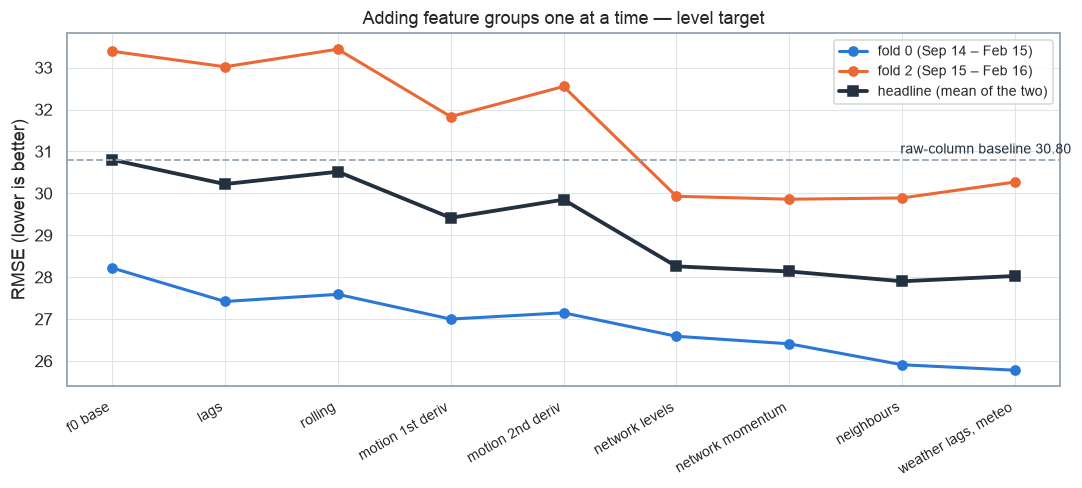

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.6))
x = np.arange(len(build))
ax.plot(x, build["fold 0"], marker="o", color=CAT[0], lw=2, label="fold 0 (Sep 14 – Feb 15)")
ax.plot(x, build["fold 2"], marker="o", color=CAT[1], lw=2, label="fold 2 (Sep 15 – Feb 16)")
ax.plot(x, build["headline"], marker="s", color=INK, lw=2.5, label="headline (mean of the two)")
ax.axhline(30.80, color=MUTED, ls="--", lw=1.2)
ax.text(len(build) - 0.5, 30.95, "raw-column baseline 30.80", ha="right", fontsize=9, color=INK)
ax.set_xticks(x)
ax.set_xticklabels([s.split(" + ")[-1] if " + " in s else s for s in build.index], rotation=30, ha="right", fontsize=9)
ax.set(ylabel="RMSE (lower is better)", title="Adding feature groups one at a time — level target")
ax.legend(fontsize=9, loc="upper right")
save(fig, "01_buildup")
plt.show()

### What this says

- **Lags help (−0.6), first-derivative motion helps (−1.1), network levels help most (−1.6),
  neighbours help (−0.2).** Together: 30.80 → 27.90.
- **Second derivatives (acceleration) hurt (+0.4) on both heating folds.** The co-pollutants'
  hour-to-hour changes are already weak (EDA: r ≈ 0.1); differencing them again is mostly
  differencing noise. Dropped.
- **Rolling stats hurt at the step they were added (+0.3) but help once the network groups
  exist** (removing them from f7 costs +0.13, see §5) — an interaction: the tree only finds a
  use for "how volatile has PM10 been" once it also knows what the city is doing. Kept.
- **Weather lags and the extra meteorology are dead weight** (+0.13), same verdict as the old
  data.

## 4. What the tree actually uses

Gain importance from the best build-up step (f7). Three columns carry three quarters of it.

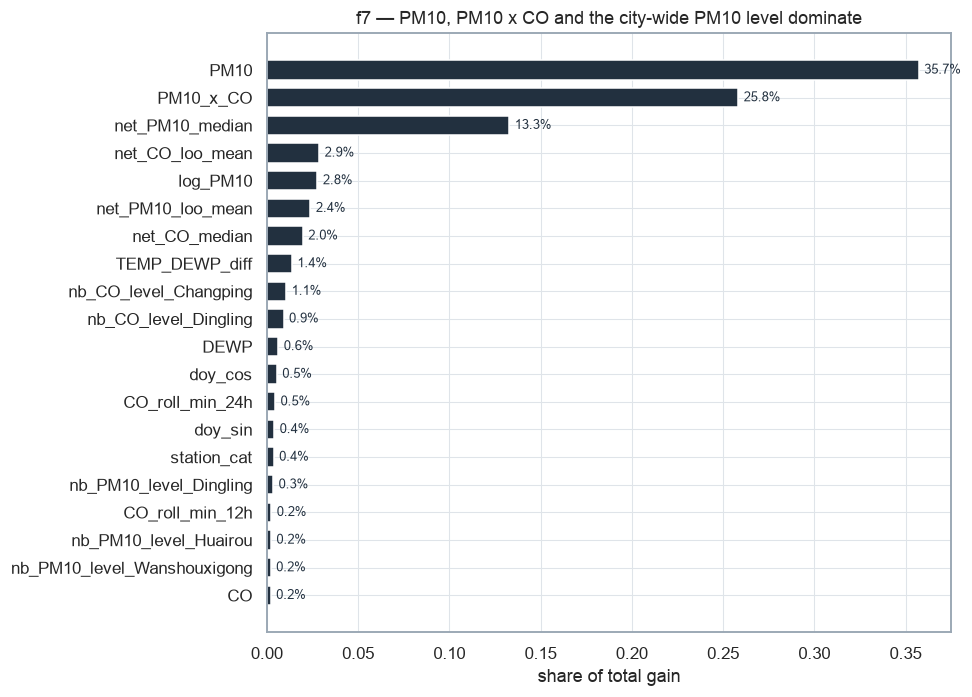

gain share by group:
raw                 0.370
physical            0.303
network_levels      0.216
neighbors           0.046
rolling             0.023
calendar            0.014
motion1             0.012
wind                0.006
lags                0.004
network_momentum    0.004
motion2             0.001
quality             0.000
missing             0.000
weather_lags        0.000
meteo_v2            0.000
deep                0.000

zero-gain columns: ['WSPM_missing', 'TEMP_missing', 'PRES_missing', 'DEWP_missing', 'RAIN_missing', 'SO2_missing', 'NO2_missing', 'wd_missing', 'o3_extreme', 'co_ceiling', 'CO_missing', 'O3_missing']


In [6]:
r7 = load("lgbm_f7")
imp = pd.Series(r7["importance"]); tot = imp.sum()
top = (imp / tot).head(20)[::-1]
fig, ax = plt.subplots(figsize=(9, 6.5))
ax.barh(top.index, top.to_numpy(), color=INK, height=0.7)
for k, v in top.items():
    ax.text(v + 0.003, k, f"{v:.1%}", va="center", fontsize=8.5, color=INK)
ax.set(xlabel="share of total gain", title="f7 — PM10, PM10 x CO and the city-wide PM10 level dominate")
save(fig, "02_importance_f7")
plt.show()

by_group = pd.Series({g: imp.reindex(c).fillna(0).sum() / tot for g, c in groups.items()}).sort_values(ascending=False)
print("gain share by group:")
print(by_group.round(3).to_string())
print("\nzero-gain columns:", [c for c, v in imp.items() if v == 0])

### What this says — and where "go deep" came from

`PM10` (36%) + `PM10 × CO` (26%) + `net_PM10_median` (13%). In words: **the model is
PM10, corrected by how much combustion is going on (CO), and by what the whole city looks like
right now.** That is the physics of the *fine fraction* — combustion produces fine particles,
so for the same PM10, more CO means more PM2.5.

So instead of adding more columns of every kind, the next step went deeper on exactly that:
a `deep` group of fine-fraction features (PM10 crossed with each combustion tracer and with
humidity, combustion *per coarse particle*, city-level products, PM10 × season) — and a change
to what the model predicts (§6).

## 5. Pruning: what can go

Backward ablation from f7 (remove one group, rerun), then the zero-gain columns.

In [7]:
prune = table([
    ("lgbm_f7", "f7 (all)"),
    ("lgbm_f7_noaccel", "f7 − acceleration"),
    ("lgbm_f7_noroll", "f7 − rolling"),
    ("lgbm_f7_noaccel_noroll", "f7 − both"),
    ("lgbm_f10_lean", "lean: f9 − acceleration − missing/quality flags"),
])
prune.drop(columns=["Δ vs previous"])

,cols,target,fold 0,fold 1,fold 2,fold 3,headline,all-fold mean,falls f2,calm f2,rises f2
run,,,,,,,,,,,
f7 (all),264,level,25.91,19.60,29.89,19.37,27.902,23.69,60.5,20.4,97.3
f7 − acceleration,258,level,25.77,19.78,29.97,19.26,27.866,23.69,59.5,20.7,96.7
f7 − rolling,206,level,26.05,20.36,30.00,19.46,28.025,23.97,59.4,20.5,96.4
f7 − both,200,level,26.12,20.29,30.04,19.57,28.078,24.00,58.9,20.7,96.7
lean: f9 − acceleration − missing/quality flags,261,level,26.83,19.50,29.31,19.52,28.070,23.79,58.7,19.9,95.0


- **Acceleration**: removing it is neutral-to-slightly-better (−0.04). Out.
- **Rolling**: removing it costs +0.13. Stays.
- **Missing/quality flags**: zero gain across all folds. Out (they cost nothing but they dilute
  `feature_fraction`).
- The resulting **lean** set (261 cols) loses ~0.2 to the deep set on both targets — the
  columns it drops are noise, but what it keeps is what matters. `f9_deep` is the final set.

## 6. Pairwise redundancy in the final set

Pairs with |r| > 0.95 on training rows. For a tree this is mostly about speed and
`feature_fraction` dilution; the list is kept for the record and for the Ridge model, where the
L2 penalty has to fight every one of these pairs.

In [8]:
real = panel[(~panel.is_pad) & (~panel.is_test)]
cols = [c for c in sets["f9_deep"] if c not in ("station_cat", "wd_cat")]
C = real[cols].astype("float32").corr().abs()
pairs = C.where(np.triu(np.ones(C.shape, dtype=bool), 1)).stack()
pairs = pairs[pairs > 0.95].sort_values(ascending=False)
print(f"{len(pairs)} pairs with |r| > 0.95 among {len(cols)} numeric columns")
imp9 = pd.Series(load("lgbm_f9_deep_ratio")["importance"])
redundant = pd.DataFrame({
    "a": [a for a, b in pairs.index], "b": [b for a, b in pairs.index], "r": pairs.round(3).to_numpy(),
    "gain a": [imp9.get(a, 0) for a, b in pairs.index], "gain b": [imp9.get(b, 0) for a, b in pairs.index],
})
redundant["drop (lower gain)"] = np.where(redundant["gain a"] >= redundant["gain b"], redundant["b"], redundant["a"])
redundant.head(30)

119 pairs with |r| > 0.95 among 282 numeric columns


,a,b,r,gain a,gain b,drop (lower gain)
0,CO_roll_mean_24h,CO_rmean_incl_24h,0.998,12455152.36,10177908.98,CO_rmean_incl_24h
1,PM10_roll_mean_24h,PM10_rmean_incl_24h,0.998,5714035.72,5525869.46,PM10_rmean_incl_24h
2,CO_roll_mean_12h,CO_rmean_incl_12h,0.996,2551291.06,2058205.20,CO_rmean_incl_12h
3,PM10_roll_mean_12h,PM10_rmean_incl_12h,0.995,2565323.93,5134221.58,PM10_roll_mean_12h
4,net_O3_loo_mean,net_O3_median,0.995,3613975.96,9486420.28,net_O3_loo_mean
5,net_PM10_loo_mean,net_PM10_median,0.993,3371089.20,7503376.81,net_PM10_loo_mean
6,net_SO2_loo_mean,net_SO2_median,0.992,14522040.05,11486187.43,net_SO2_median
7,TEMP_missing,PRES_missing,0.992,0.00,0.00,PRES_missing
8,net_PM10_loo_change_1h,net_PM10_mean_change_1h,0.991,1824000.85,1469847.83,net_PM10_mean_change_1h
9,CO_roll_mean_6h,CO_rmean_incl_6h,0.991,576712.80,971786.64,CO_roll_mean_6h


In [9]:
drop_candidates = sorted(set(redundant["drop (lower gain)"]))
print(f"{len(drop_candidates)} lower-gain members of redundant pairs:")
print(drop_candidates)

54 lower-gain members of redundant pairs:
['CO_lag_1h', 'CO_lag_2h', 'CO_lag_3h', 'CO_rmean_incl_12h', 'CO_rmean_incl_24h', 'CO_rmean_incl_3h', 'CO_roll_max_3h', 'CO_roll_max_6h', 'CO_roll_mean_3h', 'CO_roll_mean_6h', 'CO_roll_min_3h', 'DEWP_missing', 'NO2_lag_2h', 'NO2_roll_max_3h', 'NO2_roll_mean_3h', 'NO2_roll_mean_6h', 'O3_lag_1h', 'O3_lag_2h', 'O3_lag_3h', 'PM10_lag_2h', 'PM10_lag_3h', 'PM10_rmean_incl_24h', 'PM10_rmean_incl_3h', 'PM10_rmean_incl_6h', 'PM10_roll_mean_12h', 'PM10_roll_mean_3h', 'PM10_roll_mean_6h', 'PM10_x_CO', 'PM10_x_netCO', 'PRES_missing', 'RAIN_missing', 'SO2_lag_1h', 'SO2_lag_2h', 'WSPM_missing', 'logPM10_x_logCO', 'month_cos', 'month_sin', 'nb_CO_level_Aotizhongxin', 'nb_CO_level_Dongsi', 'nb_CO_level_Guanyuan', 'nb_CO_level_Nongzhanguan', 'nb_PM10_level_Aotizhongxin', 'nb_PM10_level_Dongsi', 'nb_PM10_level_Guanyuan', 'nb_PM10_level_Nongzhanguan', 'netPM10med_x_CO', 'net_CO_loo_change_1h', 'net_CO_median', 'net_NO2_loo_change_1h', 'net_NO2_median', 'net_O3_lo

## 7. Changing what the model predicts

Same features (f7, then the deep set), same LightGBM; only the target changes. Everything is
scored on the raw scale.

In [10]:
targets = table([
    ("lgbm_f7", "f7, level"),
    ("lgbm_f7_proxy", "f7, proxy: y − k_station·PM10"),
    ("lgbm_f7_log1p", "f7, log1p(y)"),
    ("lgbm_f7_te", "f7, level + climatology encoding"),
    ("lgbm_f7_wboth", "f7, level + heating/recency weights"),
    ("lgbm_f7_ratio", "f7, RATIO: y ÷ PM10, weight PM10²"),
    ("lgbm_f7_ratio_te", "f7, ratio + climatology encoding"),
    ("lgbm_f7_ratio_wboth", "f7, ratio + heating/recency weights"),
    ("lgbm_f9_deep", "deep, level"),
    ("lgbm_f9_deep_proxy", "deep, proxy"),
    ("lgbm_f9_deep_proxysm", "deep, proxy by station × month"),
    ("lgbm_f9_deep_ratio", "deep, RATIO"),
    ("lgbm_f10_lean_ratio", "lean, ratio"),
])
targets.drop(columns=["Δ vs previous"]).sort_values("headline")

,cols,target,fold 0,fold 1,fold 2,fold 3,headline,all-fold mean,falls f2,calm f2,rises f2
run,,,,,,,,,,,
"deep, RATIO",284,ratio,24.90,19.80,26.99,18.95,25.942,22.66,50.4,18.7,89.4
"lean, ratio",261,ratio,25.10,19.56,27.19,19.04,26.143,22.72,50.9,18.8,90.1
"f7, RATIO: y ÷ PM10, weight PM10²",264,ratio,24.89,19.70,27.63,19.29,26.258,22.88,49.5,19.6,90.3
"f7, proxy: y − k_station·PM10",264,proxy,26.25,21.03,28.92,19.22,27.582,23.85,54.8,20.3,93.8
"f7, level",264,level,25.91,19.60,29.89,19.37,27.902,23.69,60.5,20.4,97.3
"deep, level",284,level,26.61,19.39,29.46,19.41,28.031,23.71,58.6,20.1,95.5
"f7, level + heating/recency weights",264,level,25.87,19.58,30.29,19.16,28.079,23.72,60.4,20.9,97.6
"deep, proxy",284,proxy,26.59,20.80,29.72,19.21,28.152,24.08,56.1,20.7,97.1
"f7, level + climatology encoding",264,level,26.04,19.96,30.38,19.36,28.212,23.93,61.1,20.9,97.6


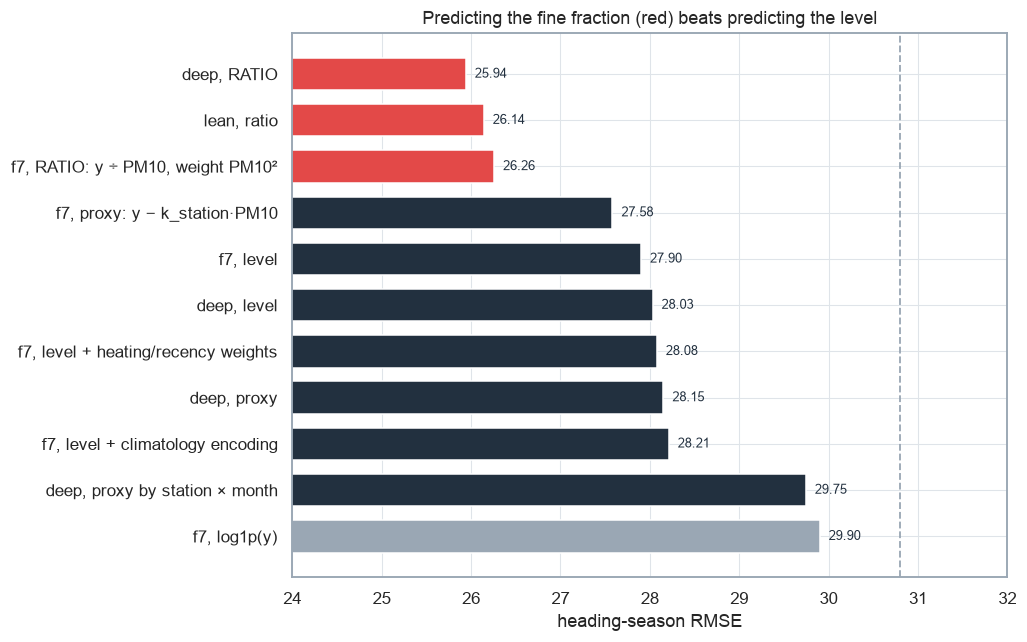

In [11]:
t = targets.drop(columns=["Δ vs previous"]).sort_values("headline", ascending=False)
fig, ax = plt.subplots(figsize=(9.5, 6))
colors = [POS if "RATIO" in i or "ratio" in i else (MUTED if "log1p" in i else INK) for i in t.index]
ax.barh(t.index, t["headline"], color=colors, height=0.7)
for i, v in zip(t.index, t["headline"]):
    ax.text(v + 0.1, i, f"{v:.2f}", va="center", fontsize=8.5, color=INK)
ax.axvline(30.80, color=MUTED, ls="--", lw=1.2)
ax.set(xlabel="heading-season RMSE", xlim=(24, 32), title="Predicting the fine fraction (red) beats predicting the level")
save(fig, "03_targets")
plt.show()

### What this says

- **The ratio target is the single biggest lever in the whole round (−1.6).** The model
  predicts `y ÷ PM10` — the fine fraction, a bounded number around 0.5–1 — with sample weight
  `PM10²`, and the prediction is multiplied back by PM10. The `PM10²` weight makes the training
  loss *identical* to squared error on the level, so this is not a different objective; it is
  the same objective re-parameterised so that the tree's leaves hold a fraction that *scales
  with PM10*. That is what lets it predict above the highest level in its training window —
  the same extrapolation problem the Δ trick solved in v2 (`Findings/v2/02`), solved
  multiplicatively.
- **The deep fine-fraction features only pay under the ratio target** (deep+level 28.03 vs
  deep+ratio 25.94). They were built to describe the fraction, and that is the target that
  asks for it.
- **The additive proxy** (`y − k·PM10`) is a smaller version of the same idea (−0.3); making
  `k` season-specific made it worse (+1.6) — a noisier anchor is a worse anchor.
- **log1p hurts by 2.0**, exactly as PROJECT.md predicted: it optimises relative error and
  under-predicts the spikes RMSE punishes hardest.
- Climatology encoding and heating/recency weights: no help on either target — the tree
  already has `station`, `month`, `hour`.

## 8. Where the error still lives

Falls / calm / rises on the hardest fold, for the yardstick and the best model, against what
the old anchor would have scored. Rows are heating-fold 2; values are RMSE.

In [12]:
def tails(name):
    r = load(name); t = r["folds"][2]["tails"]
    return {k: round(t[k]["rmse"], 1) for k in ("fall", "calm", "rise")}
pd.DataFrame({
    "old persistence (diagnostic)": {k: round(load("lgbm_f0")["folds"][2]["tails"][k]["persistence_rmse"], 1) for k in ("fall", "calm", "rise")},
    "LightGBM raw columns": tails("lgbm_f0"),
    "LightGBM f7 level": tails("lgbm_f7"),
    "LightGBM deep ratio (best)": tails("lgbm_f9_deep_ratio"),
})

,old persistence (diagnostic),LightGBM raw columns,LightGBM f7 level,LightGBM deep ratio (best)
fall,77.1,66.4,60.5,50.4
calm,9.2,23.3,20.4,18.7
rise,72.8,105.4,97.3,89.4


Every regime improved from the raw baseline to the best model — falls 66 → 50, rises 105 → 88,
calm 23 → 19. But **calm hours are still twice as bad as the old anchor's 9.2, and rises are
worse than the anchor's 73.** That gap is the cost of not knowing this hour's PM2.5: the
fine-fraction estimate carries ~19 RMSE of uncertainty even when nothing is changing.

## 9. Selection — the final feature set and why

| decision | choice | reason |
|---|---|---|
| feature set | **`f9_deep`** (284 cols) | best on the ratio target; the lean subset loses ~0.2 |
| target | **ratio** (`y ÷ PM10`, weight `PM10²`) | −1.6 vs level, better on both heating folds and in every regime |
| dropped | acceleration, missing/quality flags, weather lags, extra meteorology | hurt or zero gain |
| kept despite weak correlation | rolling stats, network momentum | earn their place once the network levels exist |
| not adopted | log target, climatology encoding, sample weights, season-specific proxy | measured, no gain or worse |

Feature exploration stops here; what remains is the algorithm/blend phase
(`Findings/v3/04-algorithms-and-blend.md`) and honest reporting of how far this gets toward
17.0.